# Exploratory Data Analysis (EDA) & Data Profiling

This notebook explores the 5 CSVs of the World Happiness Report. It documents data quality observations, harmonization decisions, and proposes a unified schema for machine learning.

## 1. Data Loading & Setup

In [1]:
# Imports for EDA
# ES: Imports para el EDA
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make src/ importable when running the notebook from notebooks/
# ES: Permite importar src/ cuando el notebook corre desde notebooks/
sys.path.insert(0, str(Path.cwd().parent))
from src.paths import DATA_RAW

def load_all_raw() -> dict[int, pd.DataFrame]:
    """Load the 5 raw CSVs keyed by year."""
    # ES: Carga los 5 CSV crudos indexados por año
    return {year: pd.read_csv(DATA_RAW / f"{year}.csv") for year in range(2015, 2020)}

dfs = load_all_raw()
print(f"Loaded {len(dfs)} datasets")

Loaded 5 datasets


### Output Interpretation
The necessary libraries were imported successfully, and the 5 raw CSV datasets corresponding to the World Happiness Report (2015-2019) were successfully loaded into memory for analysis.

## 2. Data Inspection (Schema, Types, Nulls, Duplicates)

In [2]:
# Quick inspection: shape, types, nulls, duplicates
# ES: Inspección rápida: forma, tipos, nulos, duplicados
for year, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"Year: {year} | Shape: {df.shape}")
    print(f"Nulls: {df.isna().sum().sum()} | Duplicates: {df.duplicated().sum()}")


Year: 2015 | Shape: (158, 12)
Nulls: 0 | Duplicates: 0

Year: 2016 | Shape: (157, 13)
Nulls: 0 | Duplicates: 0

Year: 2017 | Shape: (155, 12)
Nulls: 0 | Duplicates: 0

Year: 2018 | Shape: (156, 9)
Nulls: 1 | Duplicates: 0

Year: 2019 | Shape: (156, 9)
Nulls: 0 | Duplicates: 0


### Output Interpretation
This output shows the dimensions (shape) and data quality of each yearly dataset. We can observe that the datasets range from 155 to 158 rows, with varying numbers of columns. Notably, the 2018 dataset contains a single missing value, which will need to be addressed during data cleaning.

In [3]:
# Comparative column table across all years
# ES: Tabla comparativa de columnas entre todos los años
all_cols = sorted(set(c for df in dfs.values() for c in df.columns))
comparison = pd.DataFrame(
    {year: [col if col in df.columns else "—" for col in all_cols]
     for year, df in dfs.items()},
    index=all_cols,
)
comparison

,2015,2016,2017,2018,2019
Country,Country,Country,Country,—,—
Country or region,—,—,—,Country or region,Country or region
Dystopia Residual,Dystopia Residual,Dystopia Residual,—,—,—
Dystopia.Residual,—,—,Dystopia.Residual,—,—
Economy (GDP per Capita),Economy (GDP per Capita),Economy (GDP per Capita),—,—,—
Economy..GDP.per.Capita.,—,—,Economy..GDP.per.Capita.,—,—
Family,Family,Family,Family,—,—
Freedom,Freedom,Freedom,Freedom,—,—
Freedom to make life choices,—,—,—,Freedom to make life choices,Freedom to make life choices
GDP per capita,—,—,—,GDP per capita,GDP per capita


### Output Interpretation
This comparative table highlights the severe schema inconsistencies across the 5 years. There are three distinct naming conventions used (natural text, dot-notation, and verbose names), which confirms the need for a strict mapping table to harmonize the features before merging them into a single unified dataset.

In [4]:
# Missing values count per year
# ES: Conteo de valores faltantes por año
for year, df in dfs.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n--- {year} ---")
        print(missing)


--- 2018 ---
Perceptions of corruption    1
dtype: int64


### Output Interpretation
The missing values check confirms that the only `NaN` value present across all 5 datasets is located in the "Perceptions of corruption" column for the 2018 dataset.

## 3. Visualizations

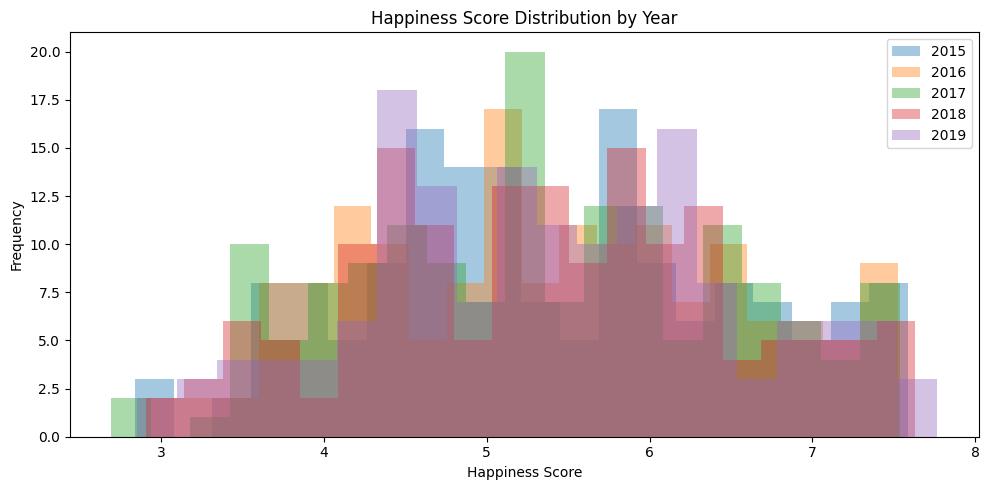

In [5]:
# Histogram of Happiness Score per year (overlay)
# ES: Histograma del Happiness Score por año (superpuesto)
score_cols = {
    2015: "Happiness Score",
    2016: "Happiness Score",
    2017: "Happiness.Score",
    2018: "Score",
    2019: "Score",
}

plt.figure(figsize=(10, 5))
for year, col in score_cols.items():
    plt.hist(dfs[year][col], bins=20, alpha=0.4, label=str(year))
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.title("Happiness Score Distribution by Year")
plt.legend()
plt.tight_layout()
plt.show()

### Output Interpretation
The overlapping histograms illustrate the distribution of the Happiness Score across the different years. The distributions appear fairly consistent and approximately normal, centered around a score of 5.3, indicating that global happiness levels remained relatively stable over this 5-year period.

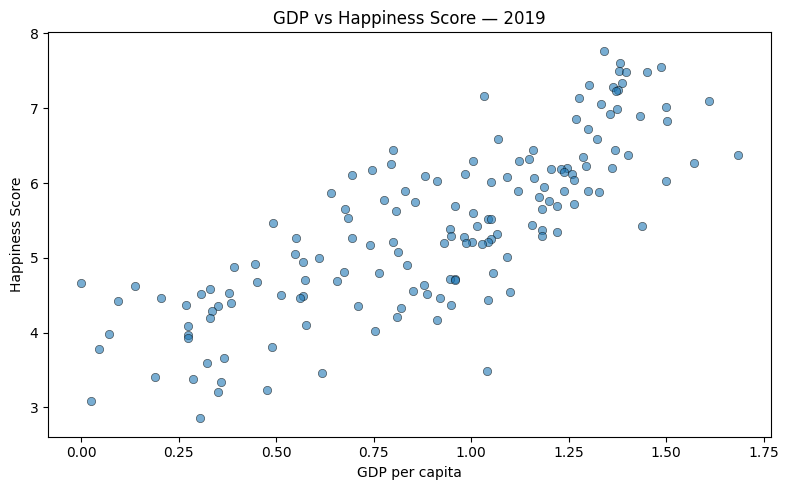

In [6]:
# Scatter: GDP vs Happiness Score (2019)
# ES: Scatter: GDP vs Happiness Score (2019)
plt.figure(figsize=(8, 5))
plt.scatter(dfs[2019]["GDP per capita"], dfs[2019]["Score"], alpha=0.6, edgecolors="k", linewidths=0.5)
plt.xlabel("GDP per capita")
plt.ylabel("Happiness Score")
plt.title("GDP vs Happiness Score — 2019")
plt.tight_layout()
plt.show()

### Output Interpretation
The scatter plot for 2019 demonstrates a strong positive linear correlation between GDP (Economy) and the Happiness Score. This suggests that wealthier countries tend to have higher reported happiness levels, making GDP a highly predictive feature for our machine learning model.

In [ ]:
# Correlation heatmap for 2019
# ES: Heatmap de correlación para 2019
numeric_cols_2019 = dfs[2019].select_dtypes(include=[np.number]).columns
corr = dfs[2019][numeric_cols_2019].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap — 2019")
plt.tight_layout()
plt.show()

### Output Interpretation
The correlation heatmap reveals how different features linearly relate to each other and to the target variable (`Happiness_Score`). Features like `GDP`, `Family` (Social Support), and `Health` show strong positive correlations with the target, while `Generosity` and `Corruption` show weaker correlations. This guides our feature selection process.

## 4. Harmonization Mapping Table

| Unified Concept | 2015 | 2016 | 2017 | 2018 | 2019 |
|---|---|---|---|---|---|
| `country` | Country | Country | Country | Country or region | Country or region |
| `happiness_score` | Happiness Score | Happiness Score | Happiness.Score | Score | Score |
| `gdp` | Economy (GDP per Capita) | Economy (GDP per Capita) | Economy..GDP.per.Capita. | GDP per capita | GDP per capita |
| `family` | Family | Family | Family | Social support | Social support |
| `health` | Health (Life Expectancy) | Health (Life Expectancy) | Health..Life.Expectancy. | Healthy life expectancy | Healthy life expectancy |
| `freedom` | Freedom | Freedom | Freedom | Freedom to make life choices | Freedom to make life choices |
| `generosity` | Generosity | Generosity | Generosity | Generosity | Generosity |
| `corruption` | Trust (Government Corruption) | Trust (Government Corruption) | Trust..Government.Corruption. | Perceptions of corruption | Perceptions of corruption |
| `region` | Region | Region | (absent → impute) | (absent → impute) | (absent → impute) |

## 5. Data Cleaning and Harmonization Decisions

### PDF Suggestions:
- **Handling Missing Values:** The PDF explicitly requests to remove or handle missing values.
- **Standardize Column Names & Data Types:** The PDF explicitly requests resolving schema inconsistencies and merging datasets.

### Assumed Decisions:
- **Imputing `Region`:** We assume joining on `Country` using the 2015 dataset is the best way to backfill missing regions for 2017-2019.
- **Imputing `Corruption`:** We assume filling the single missing value for UAE in 2018 with the yearly mean is the most robust approach.
- **Discarding `Dystopia Residual`:** Since it is missing in later years, we assume it's best to exclude it entirely for consistency.
- **Discarding `Whisker` intervals:** We assume these confidence intervals are not needed for a point-prediction regression model.